# PHYS 2550 Homework 1
## House Prices with Linear Regression

**Name:** Chengnuo Zhang  
**Date:** 18th September 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## (a) Get the data in

The original XLSX worksheet was opened in WPS Office and exported as
a comma-delimited CSV file.

Data source: [UCI Real Estate Valuation Dataset](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set)

In [2]:
csv_name = "Real estate valuation data set.csv"
csv_path = Path(csv_name)

# On Colab the file is not in the working directory, so fetch the copy
# that sits next to this notebook in the GitHub repository.
if not csv_path.exists():
    from urllib.request import urlretrieve
    from urllib.parse import quote

    repo_url = (
        "https://raw.githubusercontent.com/"
        "ChengnuoDaisy/phys2550-hw1/main/"
    )
    urlretrieve(repo_url + quote(csv_name), csv_name)
    print("Downloaded", csv_name)

# Read the column names from the first line
with csv_path.open("r", encoding="utf-8-sig") as file:
    column_names = file.readline().strip().split(",")

# Read numerical data
data = np.loadtxt(
    csv_path,
    delimiter=",",
    skiprows=1
)

print("Column names:")
print(column_names)

print("\nFirst five rows:")
print(data[:5])

print("\nData shape:")
print(data.shape)

print("\nNumber of houses:")
print(data.shape[0])

Column names:
['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']

First five rows:
[[1.0000000e+00 2.0129170e+03 3.2000000e+01 8.4878820e+01 1.0000000e+01
  2.4982980e+01 1.2154024e+02 3.7900000e+01]
 [2.0000000e+00 2.0129170e+03 1.9500000e+01 3.0659470e+02 9.0000000e+00
  2.4980340e+01 1.2153951e+02 4.2200000e+01]
 [3.0000000e+00 2.0135830e+03 1.3300000e+01 5.6198450e+02 5.0000000e+00
  2.4987460e+01 1.2154391e+02 4.7300000e+01]
 [4.0000000e+00 2.0135000e+03 1.3300000e+01 5.6198450e+02 5.0000000e+00
  2.4987460e+01 1.2154391e+02 5.4800000e+01]
 [5.0000000e+00 2.0128330e+03 5.0000000e+00 3.9056840e+02 5.0000000e+00
  2.4979370e+01 1.2154245e+02 4.3100000e+01]]

Data shape:
(414, 8)

Number of houses:
414


In [3]:
column_descriptions = [
    "House ID",
    "Transaction date",
    "House age",
    "Distance to the nearest MRT station",
    "Number of convenience stores within walking distance",
    "Latitude",
    "Longitude",
    "House price per unit area"
]

column_units = [
    "none",
    "year, fractionally encoded",
    "years",
    "meters",
    "count",
    "degrees",
    "degrees",
    "10,000 New Taiwan dollars per ping (1 ping = 3.3 m^2)"
]

# np.loadtxt above would have raised an error on an empty or non-numeric
# field, so check instead that every line really has 8 fields.
with csv_path.open("r", encoding="utf-8-sig") as file:
    field_counts = set(
        len(line.strip().split(","))
        for line in file
        if line.strip()
    )

print("Number of fields found on each line:", field_counts)
print()

for i in range(data.shape[1]):
    values = data[:, i]

    print(f"{column_names[i]}")
    print(f"  Meaning: {column_descriptions[i]}")
    print(f"  Unit: {column_units[i]}")
    print(f"  Range: {values.min():.5f} to {values.max():.5f}")
    print(f"  NaN values: {np.isnan(values).sum()}")
    print()

Number of fields found on each line: {8}

No
  Meaning: House ID
  Unit: none
  Range: 1.00000 to 414.00000
  NaN values: 0

X1 transaction date
  Meaning: Transaction date
  Unit: year, fractionally encoded
  Range: 2012.66700 to 2013.58300
  NaN values: 0

X2 house age
  Meaning: House age
  Unit: years
  Range: 0.00000 to 43.80000
  NaN values: 0

X3 distance to the nearest MRT station
  Meaning: Distance to the nearest MRT station
  Unit: meters
  Range: 23.38284 to 6488.02100
  NaN values: 0

X4 number of convenience stores
  Meaning: Number of convenience stores within walking distance
  Unit: count
  Range: 0.00000 to 10.00000
  NaN values: 0

X5 latitude
  Meaning: Latitude
  Unit: degrees
  Range: 24.93207 to 25.01459
  NaN values: 0

X6 longitude
  Meaning: Longitude
  Unit: degrees
  Range: 121.47353 to 121.56627
  NaN values: 0

Y house price of unit area
  Meaning: House price per unit area
  Unit: 10,000 New Taiwan dollars per ping (1 ping = 3.3 m^2)
  Range: 7.60000 to 1

In [4]:
# Check for repeated properties by comparing the six feature columns
# and ignoring the ID and the price.
feature_block = data[:, 1:7]
unique_rows = np.unique(feature_block, axis=0)

print("Rows in the file:", len(feature_block))
print("Distinct feature combinations:", len(unique_rows))
print("Repeated rows:", len(feature_block) - len(unique_rows))

# Count the houses that are a long way from an MRT station.
far_from_mrt = (data[:, 3] > 4000).sum()

print()
print("Houses more than 4000 m from an MRT station:", far_from_mrt)
print(f"  that is {100 * far_from_mrt / len(data):.1f}% of the data set")

Rows in the file: 414
Distinct feature combinations: 394
Repeated rows: 20

Houses more than 4000 m from an MRT station: 33
  that is 8.0% of the data set


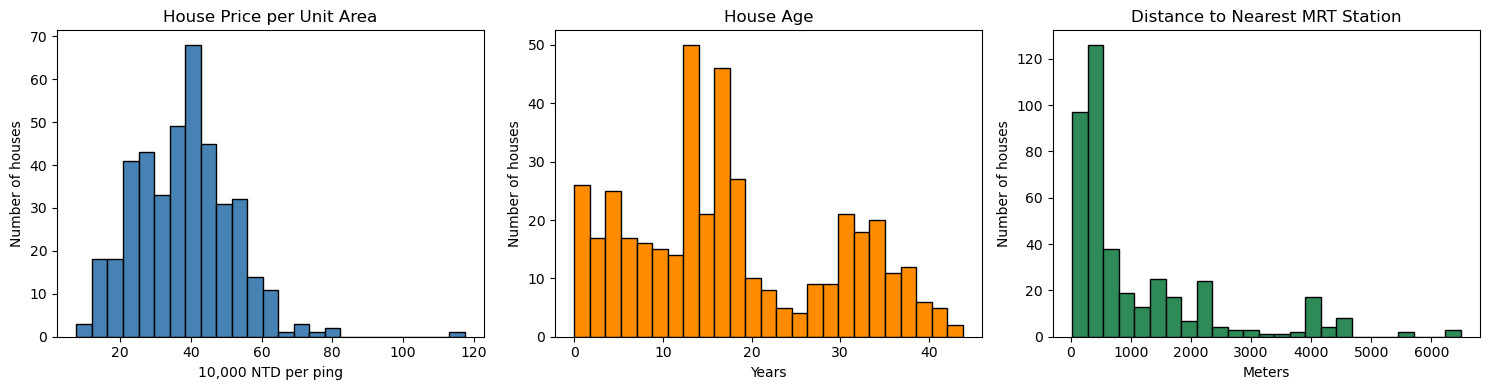

In [5]:
house_age = data[:, 2]
mrt_distance = data[:, 3]
house_price = data[:, 7]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target: house price
axes[0].hist(
    house_price,
    bins=25,
    color="steelblue",
    edgecolor="black"
)
axes[0].set_title("House Price per Unit Area")
axes[0].set_xlabel("10,000 NTD per ping")
axes[0].set_ylabel("Number of houses")

# Feature 1: house age
axes[1].hist(
    house_age,
    bins=25,
    color="darkorange",
    edgecolor="black"
)
axes[1].set_title("House Age")
axes[1].set_xlabel("Years")
axes[1].set_ylabel("Number of houses")

# Feature 2: distance to MRT
axes[2].hist(
    mrt_distance,
    bins=25,
    color="seagreen",
    edgecolor="black"
)
axes[2].set_title("Distance to Nearest MRT Station")
axes[2].set_xlabel("Meters")
axes[2].set_ylabel("Number of houses")

plt.tight_layout()

# save picture
plt.savefig(
    "part_a_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Initial observations

There are 414 rows and eight columns: an ID column, six features, and
the price. Every line has eight fields and nothing is missing.

The price distribution is skewed to the right. About 87% of the houses
sit between 20 and 60, and one house is at 117.5, well away from
everything else. House age is not a single smooth peak either; it looks
like two or three groups, and 17 houses are listed with an age of 0.

Distance to the MRT is skewed much more strongly. The median is 492 m
but the mean is 1084 m, and 33 houses (8%) are further than 4000 m. The
scale is what I will have to deal with in (c): MRT distance runs up to
6488 while house age never passes 44.

One other thing I noticed is that 20 of the 414 rows repeat a set of
feature values that already appeared earlier, so some properties were
sold more than once. Their prices are not always the same, which means
no model built on these six features can get the error down to zero.

## (b) One feature

### Linear regression with house age

Using house age as the only feature, the model is

$$
\hat{y}_i = w_0 + w_1x_i.
$$

For $n$ observations, the mean squared error is

$$
L(w_0,w_1)
=
\frac{1}{n}\sum_{i=1}^{n}
(\hat{y}_i-y_i)^2
=
\frac{1}{n}\sum_{i=1}^{n}
(w_0+w_1x_i-y_i)^2.
$$

The derivative with respect to the intercept is

$$
\frac{\partial L}{\partial w_0}
=
\frac{1}{n}\sum_{i=1}^{n}
2(w_0+w_1x_i-y_i)
\frac{\partial(w_0+w_1x_i-y_i)}{\partial w_0}
$$

$$
\frac{\partial L}{\partial w_0}
=
\frac{2}{n}\sum_{i=1}^{n}
(w_0+w_1x_i-y_i).
$$

The derivative with respect to the slope is

$$
\frac{\partial L}{\partial w_1}
=
\frac{1}{n}\sum_{i=1}^{n}
2(w_0+w_1x_i-y_i)
\frac{\partial(w_0+w_1x_i-y_i)}{\partial w_1}
$$

$$
\frac{\partial L}{\partial w_1}
=
\frac{2}{n}\sum_{i=1}^{n}
(w_0+w_1x_i-y_i)x_i.
$$

The gradient-descent updates are

$$
w_0 \leftarrow w_0-\eta\frac{\partial L}{\partial w_0},
\qquad
w_1 \leftarrow w_1-\eta\frac{\partial L}{\partial w_1},
$$

where $\eta$ is the learning rate.

In [6]:
# X2 house age
x = data[:, 2]

# Y house price per unit area
y = data[:, 7]

n = len(y)

print("Number of observations:", n)
print("House-age shape:", x.shape)
print("Target shape:", y.shape)

Number of observations: 414
House-age shape: (414,)
Target shape: (414,)


In [7]:
# Try a few learning rates on a short run and keep the largest one
# that does not blow up.
test_rates = [0.0005, 0.001, 0.002, 0.0023, 0.005]
test_epochs = 2000

for rate in test_rates:
    w0_test = 0.0
    w1_test = 0.0
    diverged = False

    with np.errstate(over="ignore", invalid="ignore"):
        for epoch in range(test_epochs):
            error_test = (w0_test + w1_test * x) - y
            loss_test = np.mean(error_test ** 2)

            # The loss starts near 2000, so anything this large is
            # running away rather than converging.
            if not np.isfinite(loss_test) or loss_test > 1e6:
                diverged = True
                break

            w0_test = w0_test - rate * (2.0 / n) * np.sum(error_test)
            w1_test = w1_test - rate * (2.0 / n) * np.sum(error_test * x)

    if diverged:
        print(f"learning rate {rate}: diverged at epoch {epoch}")
    else:
        print(f"learning rate {rate}: loss after {test_epochs} epochs = {loss_test:.4f}")

learning rate 0.0005: loss after 2000 epochs = 339.9351
learning rate 0.001: loss after 2000 epochs = 227.3987
learning rate 0.002: loss after 2000 epochs = 181.4319
learning rate 0.0023: diverged at epoch 85
learning rate 0.005: diverged at epoch 3


In [8]:
# Initial parameter values
w0 = 0.0
w1 = 0.0

learning_rate = 0.002
epochs = 10000

loss_history = []

for epoch in range(epochs):
    # Predictions using current parameters
    y_pred = w0 + w1 * x

    # Prediction errors
    error = y_pred - y

    # Mean squared error
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Gradients derived above
    dw0 = (2.0 / n) * np.sum(error)
    dw1 = (2.0 / n) * np.sum(error * x)

    # Update both parameters
    w0 = w0 - learning_rate * dw0
    w1 = w1 - learning_rate * dw1

# Recalculate predictions and loss using final parameters
y_pred = w0 + w1 * x
final_loss = np.mean((y_pred - y) ** 2)

print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"Final w0: {w0:.6f}")
print(f"Final w1: {w1:.6f}")
print(f"Final MSE loss: {final_loss:.6f}")

Learning rate: 0.002
Epochs: 10000
Final w0: 42.434336
Final w1: -0.251474
Final MSE loss: 176.500474


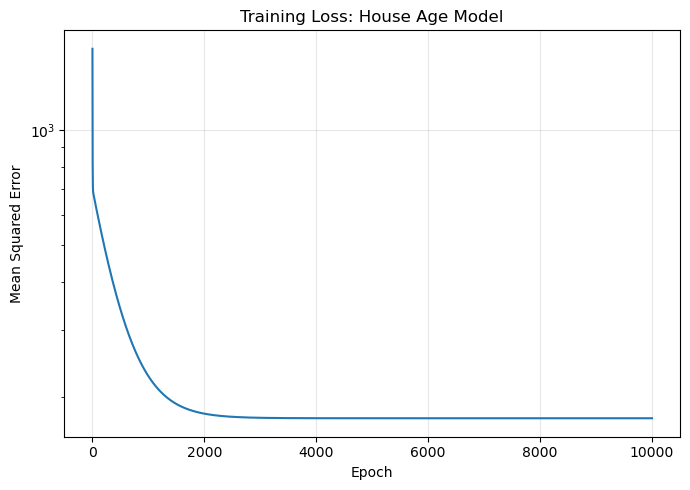

In [9]:
plt.figure(figsize=(7, 5))

plt.plot(loss_history)
plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training Loss: House Age Model")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "part_b_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

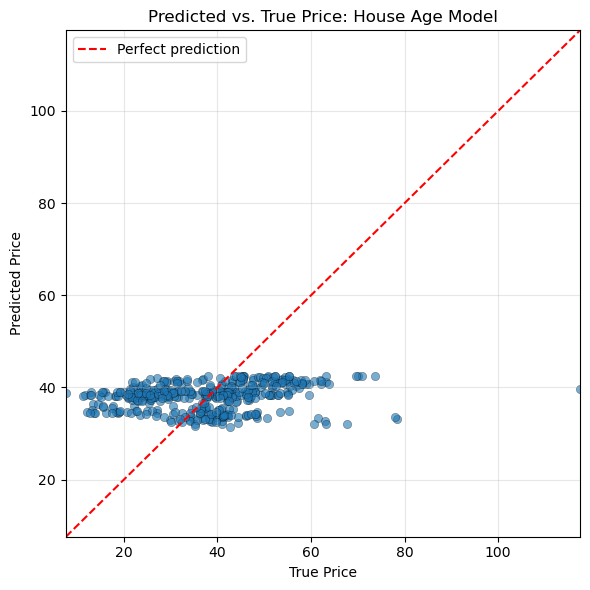

In [10]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y,
    y_pred,
    alpha=0.6,
    edgecolor="black",
    linewidth=0.3
)

plot_min = min(y.min(), y_pred.min())
plot_max = max(y.max(), y_pred.max())

# Perfect-prediction reference line
plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    color="red",
    label="Perfect prediction"
)

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs. True Price: House Age Model")
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "part_b_predicted_vs_true.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Results for the one-feature model

The scan above shows where the usable range ends. 0.0005 and 0.001 are
stable but after 2000 epochs they are still a long way from the
minimum, 0.002 is the largest value that still works, and 0.0023 and
0.005 blow up. So I used 0.002 and ran it for 10,000 epochs, which is
where the loss curve goes flat.

The fitted model is

$$
\hat{y} = 42.434336 - 0.251474x,
$$

with a final mean squared error of

$$
L = 176.500474.
$$

The loss is stable to six decimals, although the weights are still
drifting a little. The bonus section checks how long full convergence
actually takes.

$w_1$ is negative, so older houses are worth slightly less. But house
age on its own is a bad predictor. Every prediction lands between about
31 and 42, while the real prices run from 7.6 to 117.5, so the scatter
plot is basically a vertical stripe. Houses of the same age can differ
by tens of units in price and a single line has no way to follow that.
The cheapest and the most expensive houses are missed completely.

## (c) More features

### Linear regression with multiple features

I used house age and distance to the nearest MRT station as the two
input features. For each house, a constant 1 is appended to the feature
vector:

$$
\mathbf{x}_i =
\begin{bmatrix}
1 \\
x_{i1} \\
x_{i2}
\end{bmatrix},
\qquad
\mathbf{w} =
\begin{bmatrix}
w_0 \\
w_1 \\
w_2
\end{bmatrix}.
$$

The prediction for one observation is

$$
\hat{y}_i = \mathbf{w}^{T}\mathbf{x}_i.
$$

For the complete data set, the predictions and mean squared error are

$$
\hat{\mathbf{y}} = X\mathbf{w},
$$

$$
L(\mathbf{w})
=
\frac{1}{n}
(X\mathbf{w}-\mathbf{y})^T
(X\mathbf{w}-\mathbf{y}).
$$

The gradient is

$$
\nabla_{\mathbf{w}}L
=
\frac{2}{n}
X^T(X\mathbf{w}-\mathbf{y}).
$$

The gradient-descent update is

$$
\mathbf{w}
\leftarrow
\mathbf{w}
-
\eta
\frac{2}{n}
X^T(X\mathbf{w}-\mathbf{y}).
$$

In [11]:
def gradient_descent(X_features, y, learning_rate, epochs, verbose=True):
    """
    Run linear-regression gradient descent for any number of features.

    X_features: shape (number of observations, number of features)
    y:          shape (number of observations,)
    verbose:    print a message if training stops early
    """

    n = len(y)

    # Add a column of ones for the intercept w0
    X = np.column_stack([
        np.ones(n),
        X_features
    ])

    # One weight for the intercept and one for each feature
    weights = np.zeros(X.shape[1])

    loss_history = []

    for epoch in range(epochs):
        y_pred = X @ weights
        error = y_pred - y

        # Raw features may cause numerical overflow
        with np.errstate(over="ignore", invalid="ignore"):
            loss = np.mean(error ** 2)

        if not np.isfinite(loss):
            if verbose:
                print(
                    f"Training stopped at epoch {epoch}: "
                    "the loss became non-finite."
                )
            break

        loss_history.append(loss)

        gradient = (2.0 / n) * (X.T @ error)
        weights = weights - learning_rate * gradient

    return weights, np.array(loss_history)

In [12]:
# Columns 2 and 3: house age and MRT distance
X_raw = data[:, [2, 3]]

learning_rate_c = 0.002
epochs_c = 10000

weights_raw, raw_loss_history = gradient_descent(
    X_raw,
    y,
    learning_rate_c,
    epochs_c
)

print("Number of completed epochs:", len(raw_loss_history))
print("Raw-feature weights:", weights_raw)

if len(raw_loss_history) > 0:
    print("Last finite raw-feature loss:", raw_loss_history[-1])

Training stopped at epoch 38: the loss became non-finite.
Number of completed epochs: 38
Raw-feature weights: [-1.90119078e+148 -3.43211353e+149 -4.84766966e+151]
Last finite raw-feature loss: 5.31502425813881e+301


In [13]:
# Maybe the learning rate was just too big. Try much smaller ones on
# the same raw features.
raw_test_rates = [1e-5, 1e-6, 5e-7, 3e-7, 1e-7]

for rate in raw_test_rates:
    weights_test, loss_test = gradient_descent(
        X_raw,
        y,
        rate,
        epochs_c,
        verbose=False
    )

    if len(loss_test) < epochs_c:
        print(f"learning rate {rate:g}: diverged at epoch {len(loss_test)}")
    else:
        print(f"learning rate {rate:g}: survived, final loss = {loss_test[-1]:.4f}")

learning rate 1e-05: diverged at epoch 88
learning rate 1e-06: diverged at epoch 232
learning rate 5e-07: diverged at epoch 615
learning rate 3e-07: survived, final loss = 714.3260
learning rate 1e-07: survived, final loss = 879.6713


In [14]:
##standardization
feature_means = X_raw.mean(axis=0)
feature_stds = X_raw.std(axis=0)

X_normalized = (
    X_raw - feature_means
) / feature_stds

print("Original feature means:")
print(feature_means)

print("\nOriginal feature standard deviations:")
print(feature_stds)

print("\nNormalized means:")
print(X_normalized.mean(axis=0))

print("\nNormalized standard deviations:")
print(X_normalized.std(axis=0))

Original feature means:
[  17.71256039 1083.88568891]

Original feature standard deviations:
[  11.37871718 1260.58438688]

Normalized means:
[-9.22504156e-17 -1.26576152e-16]

Normalized standard deviations:
[1. 1.]


In [15]:
weights_normalized, normalized_loss_history = gradient_descent(
    X_normalized,
    y,
    learning_rate_c,
    epochs_c
)

# Final prediction and loss
X_design_normalized = np.column_stack([
    np.ones(len(y)),
    X_normalized
])

y_pred_multi = X_design_normalized @ weights_normalized

final_loss_multi = np.mean(
    (y_pred_multi - y) ** 2
)

print("Learning rate:", learning_rate_c)
print("Epochs:", epochs_c)
print("Final normalized weights:", weights_normalized)
print(f"Final multi-feature MSE: {final_loss_multi:.6f}")
print(f"One-feature MSE: {final_loss:.6f}")

Learning rate: 0.002
Epochs: 10000
Final normalized weights: [37.98019324 -2.62878615 -9.087074  ]
Final multi-feature MSE: 93.979770
One-feature MSE: 176.500474


In [16]:
# The weights above belong to the normalized features. Undo the
# scaling so they can be read in the original units.
weights_original_units = weights_normalized[1:] / feature_stds

intercept_original_units = weights_normalized[0] - np.sum(
    weights_normalized[1:] * feature_means / feature_stds
)

print("Weights expressed in the original units:")
print(f"  intercept:    {intercept_original_units:.6f}")
print(f"  house age:    {weights_original_units[0]:.6f} per year")
print(f"  MRT distance: {weights_original_units[1]:.8f} per meter")
print(f"                {1000 * weights_original_units[1]:.4f} per kilometer")

Weights expressed in the original units:
  intercept:    49.885586
  house age:    -0.231027 per year
  MRT distance: -0.00720862 per meter
                -7.2086 per kilometer


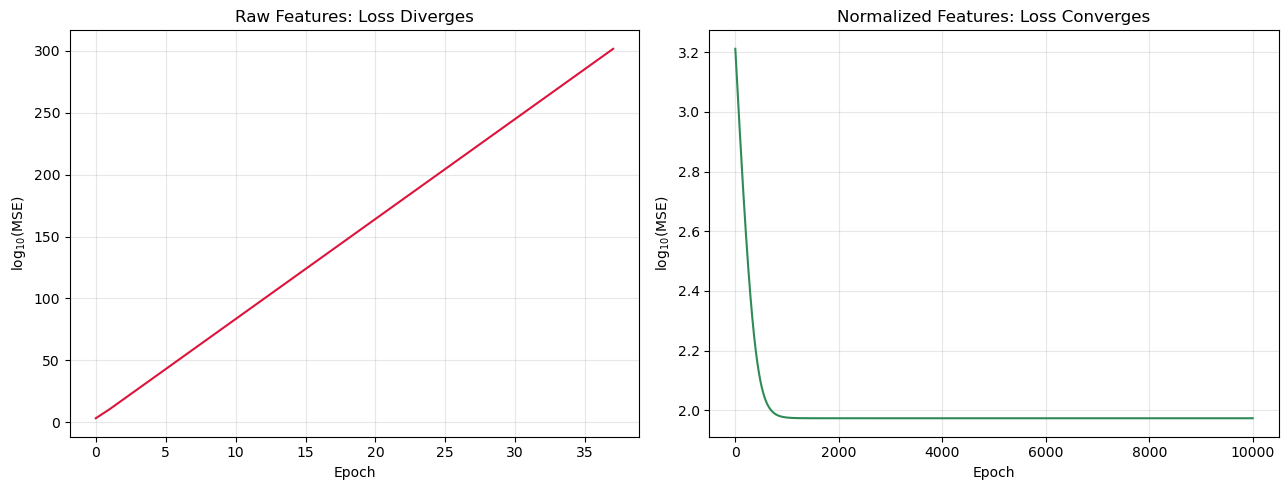

In [17]:
raw_log_loss = np.log10(raw_loss_history)
normalized_log_loss = np.log10(
    normalized_loss_history
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    raw_log_loss,
    color="crimson"
)
axes[0].set_title("Raw Features: Loss Diverges")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel(r"$\log_{10}(\mathrm{MSE})$")
axes[0].grid(alpha=0.3)

axes[1].plot(
    normalized_log_loss,
    color="seagreen"
)
axes[1].set_title(
    "Normalized Features: Loss Converges"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel(r"$\log_{10}(\mathrm{MSE})$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "part_c_raw_vs_normalized_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### What went wrong, and why normalizing fixes it

With the raw features gradient descent blew up after 38 epochs. The
gradient for feature $j$ is
$\frac{2}{n}\sum_i(\hat{y}_i-y_i)\,x_{ij}$, so it scales with the size
of the feature itself. MRT distance goes up to 6488 and house age only
to 44, so the MRT part of the gradient is something like a thousand
times bigger. A step of 0.002 that is reasonable for age is then about
a thousand times too big for MRT distance, and once the first step
overshoots, the error grows, the next step is worse, and it runs off to
infinity.

My first thought was to just make the learning rate smaller, but the
scan above shows that is not enough. Even $5\times10^{-7}$ still
diverges, and $3\times10^{-7}$, the first value that survives all
10,000 epochs, only reaches a loss of 714.3, which is worse than using
house age by itself. That is the same problem seen from the other side:
a step small enough to be safe for MRT distance is far too small for
house age, so age barely moves. No single learning rate works for both
features at once.

Normalizing removes the imbalance instead of working around it. Once
both features have mean 0 and standard deviation 1, their gradient
components are about the same size, so one learning rate suits both,
and the same 0.002 that diverged before now converges smoothly.

The MSE drops from 176.500 in (b) to 93.980 here, about 47% lower, so
distance to the MRT carries information that house age does not.

Putting the weights back into the original units gives

$$
\hat{y} = 49.886 - 0.2310\,x_{\mathrm{age}} - 0.0072086\,x_{\mathrm{MRT}},
$$


## (d) What did we learn 

In [18]:
# Check each feature: how well it correlates with the price, and the
# MSE when it is added to house age as a second feature.
feature_columns = [0, 1, 3, 4, 5, 6]

print(f"{'feature':<42}{'corr':>9}{'MSE with age':>15}")
print("-" * 66)
print(f"{'(house age alone)':<42}{np.corrcoef(house_age, y)[0, 1]:>9.4f}{final_loss:>15.3f}")

for i in feature_columns:
    correlation = np.corrcoef(data[:, i], y)[0, 1]

    pair = data[:, [2, i]]
    pair = (pair - pair.mean(axis=0)) / pair.std(axis=0)

    weights_pair, loss_pair = gradient_descent(
        pair,
        y,
        learning_rate_c,
        epochs_c,
        verbose=False
    )

    print(f"{column_names[i]:<42}{correlation:>9.4f}{loss_pair[-1]:>15.3f}")

feature                                        corr   MSE with age
------------------------------------------------------------------
(house age alone)                           -0.2106        176.500
No                                          -0.0286        176.268
X1 transaction date                          0.0875        174.964
X3 distance to the nearest MRT station      -0.6736         93.980
X4 number of convenience stores              0.5710        113.907
X5 latitude                                  0.5463        118.872
X6 longitude                                 0.5233        127.768


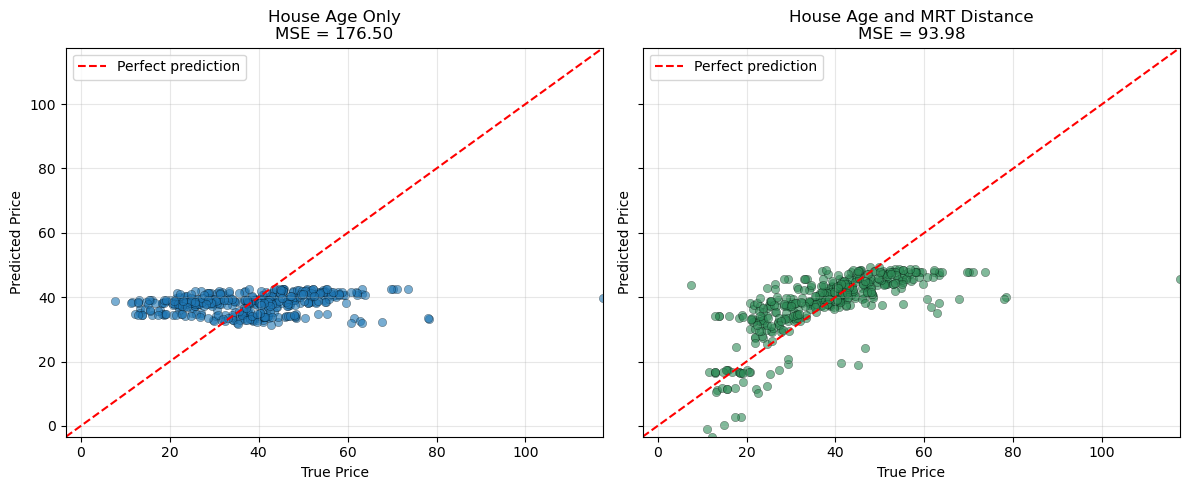

In [19]:
# y_pred: prediction from the age-only model
# y_pred_multi: prediction from the normalized two-feature model

plot_min = min(
    y.min(),
    y_pred.min(),
    y_pred_multi.min()
)

plot_max = max(
    y.max(),
    y_pred.max(),
    y_pred_multi.max()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

# Age-only model
axes[0].scatter(
    y,
    y_pred,
    alpha=0.6,
    edgecolor="black",
    linewidth=0.3
)
axes[0].plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "r--",
    label="Perfect prediction"
)
axes[0].set_title(
    f"House Age Only\nMSE = {final_loss:.2f}"
)
axes[0].set_xlabel("True Price")
axes[0].set_ylabel("Predicted Price")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Age and MRT-distance model
axes[1].scatter(
    y,
    y_pred_multi,
    alpha=0.6,
    color="seagreen",
    edgecolor="black",
    linewidth=0.3
)
axes[1].plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "r--",
    label="Perfect prediction"
)
axes[1].set_title(
    f"House Age and MRT Distance\n"
    f"MSE = {final_loss_multi:.2f}"
)
axes[1].set_xlabel("True Price")
axes[1].set_ylabel("Predicted Price")
axes[1].legend()
axes[1].grid(alpha=0.3)

for ax in axes:
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)

plt.tight_layout()
plt.savefig(
    "part_d_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

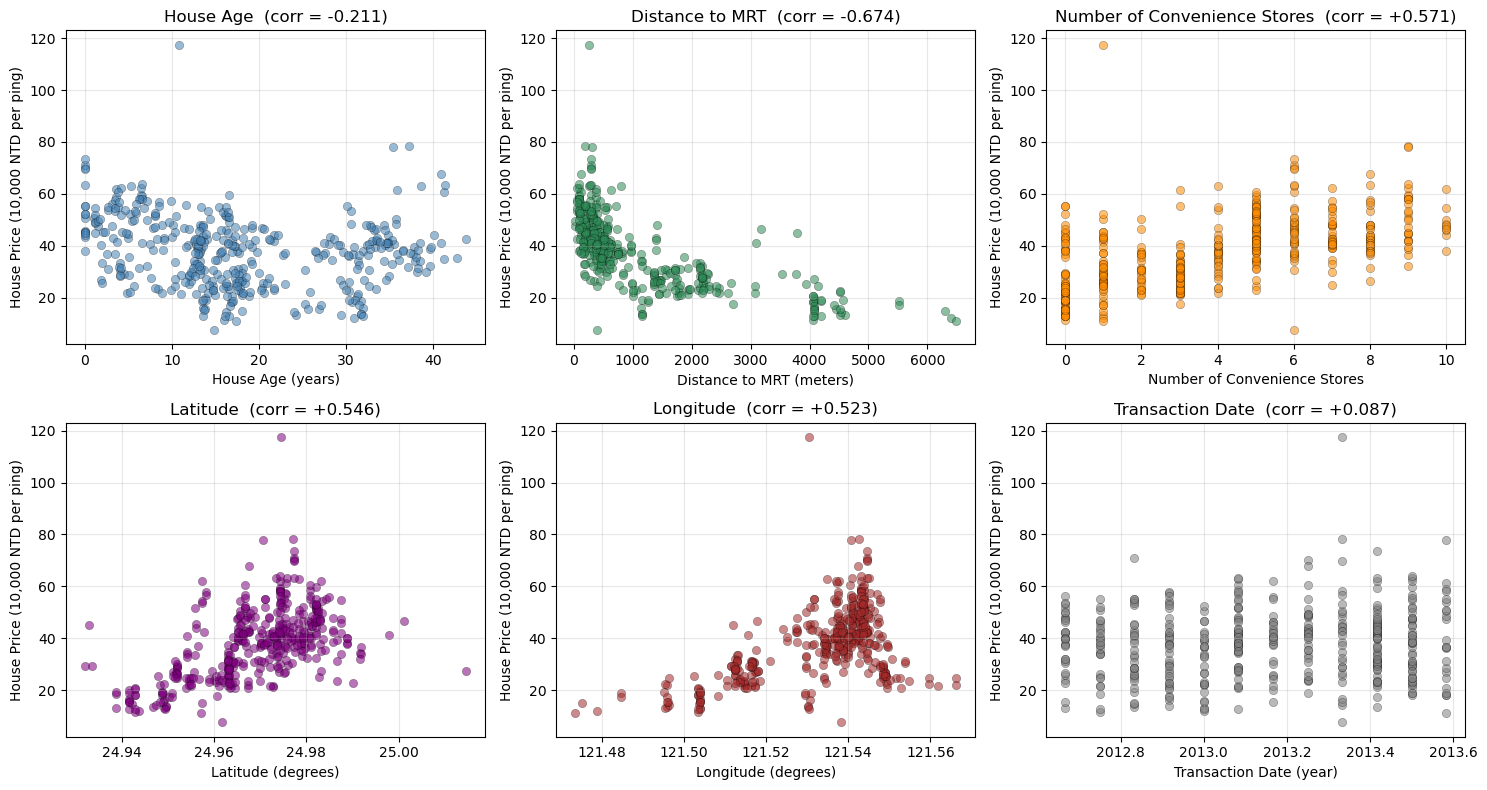

In [20]:
# Price against each of the six features, so the table above can also
# be checked by eye.
feature_plot_columns = [2, 3, 4, 5, 6, 1]

feature_plot_names = [
    "House Age",
    "Distance to MRT",
    "Number of Convenience Stores",
    "Latitude",
    "Longitude",
    "Transaction Date"
]

feature_plot_labels = [
    "House Age (years)",
    "Distance to MRT (meters)",
    "Number of Convenience Stores",
    "Latitude (degrees)",
    "Longitude (degrees)",
    "Transaction Date (year)"
]

feature_plot_colors = [
    "steelblue",
    "seagreen",
    "darkorange",
    "purple",
    "brown",
    "gray"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for position in range(len(feature_plot_columns)):
    column = feature_plot_columns[position]
    correlation = np.corrcoef(data[:, column], y)[0, 1]

    axes[position].scatter(
        data[:, column],
        y,
        alpha=0.55,
        color=feature_plot_colors[position],
        edgecolor="black",
        linewidth=0.3
    )

    axes[position].set_title(
        f"{feature_plot_names[position]}  (corr = {correlation:+.3f})"
    )
    axes[position].set_xlabel(feature_plot_labels[position])
    axes[position].set_ylabel("House Price (10,000 NTD per ping)")
    axes[position].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "part_d_price_vs_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### What did we learn?

Adding MRT distance took the MSE from 176.50 down to 93.98, a drop of
about 47%. The predicted against true plots show where that comes from.
The age-only model puts every prediction in a narrow band between 31
and 42, which cannot possibly cover data running from 7.6 to 117.5,
while the two-feature model spreads its predictions over a much more
sensible range. It is still not good, though: the expensive houses are
badly underpredicted and there is a lot of scatter around the diagonal.

The table at the start of this section says which features are worth
anything, and the six scatter plots show the same thing by eye. MRT
distance is the strongest by a wide margin. Convenience stores,
latitude and longitude are useful as well, and I think that is because
all four are really measuring the same thing, which is how central the
house is. Longitude is the clearest example of why a correlation on its
own can mislead. Its correlation is $+0.52$, but the scatter is not a
slope at all. It climbs to a peak around 121.54 and falls away on both
sides, so a linear term cannot make proper use of it. House age is
weak. Transaction date barely helps, and the plot makes that obvious,
since the twelve columns of points all sit at roughly the same height
over a window of only one year. The ID column does nothing at all,
which is what you would hope, since it is only a row number.

What limited me in (c) was the feature scale. It made the raw fit
diverge, and even at a learning rate small enough to be stable it was
too slow to be useful. Normalizing fixed that, and after that neither
the learning rate nor the number of epochs was the problem: the bonus
section shows the weights land on the exact answer after 4355 epochs,
so 10,000 was already more than enough. What holds the model back now
is the model itself. The plot of price against MRT distance is clearly
curved, falling quickly over the first 1000 m or so and then levelling
off, and a straight line cannot do that. The house at 117.5 also pulls
hard on a squared loss, and the 20 repeated rows with different prices
mean there is some error I could not remove anyway.

If I did this again I would split the data into a training and a test
set and compute the mean and standard deviation from the training set
only, so that the test error means something. I would add the
convenience-store count and the coordinates, using $\log$ of the MRT
distance instead of the distance itself to straighten out that curve,
and for the coordinates something like the distance from the centre of
the city rather than the raw latitude and longitude. I would also look
at the 117.5 house and the repeated rows before fitting, and quote
$R^2$ next to the MSE, since the MSE on its own is hard to judge.

## Bonus: Closed-form solution

In [21]:
# Closed-form solution using the normal equation
weights_closed_form = (
    np.linalg.inv(
        X_design_normalized.T
        @ X_design_normalized
    )
    @ X_design_normalized.T
    @ y
)

y_pred_closed_form = (
    X_design_normalized
    @ weights_closed_form
)

closed_form_loss = np.mean(
    (y_pred_closed_form - y) ** 2
)

weight_difference = (
    weights_normalized
    - weights_closed_form
)

print("Gradient-descent weights:")
print(weights_normalized)

print("\nClosed-form weights:")
print(weights_closed_form)

print("\nWeight differences:")
print(weight_difference)

print(
    "\nMaximum absolute difference:",
    np.max(np.abs(weight_difference))
)

print(
    "Closed-form MSE:",
    closed_form_loss
)

Gradient-descent weights:
[37.98019324 -2.62878615 -9.087074  ]

Closed-form weights:
[37.98019324 -2.62878615 -9.087074  ]

Weight differences:
[-8.88178420e-13 -5.86197757e-14  2.23820962e-13]

Maximum absolute difference: 8.881784197001252e-13
Closed-form MSE: 93.97976963938086


In [22]:
tolerance = 1e-6

weights_check = np.zeros(
    X_design_normalized.shape[1]
)

epochs_to_tolerance = None

for epoch in range(1, epochs_c + 1):
    y_pred_check = (
        X_design_normalized
        @ weights_check
    )

    error_check = y_pred_check - y

    gradient_check = (
        (2.0 / len(y))
        * (
            X_design_normalized.T
            @ error_check
        )
    )

    weights_check = (
        weights_check
        - learning_rate_c * gradient_check
    )

    max_difference = np.max(
        np.abs(
            weights_check
            - weights_closed_form
        )
    )

    if max_difference < tolerance:
        epochs_to_tolerance = epoch
        break

print("Tolerance:", tolerance)
print(
    "Epochs needed:",
    epochs_to_tolerance
)
print(
    "Maximum weight difference:",
    max_difference
)

Tolerance: 1e-06
Epochs needed: 4355
Maximum weight difference: 9.9764494621013e-07


### Bonus: Closed-form solution

For the normalized two-feature model the normal equation gives

$$
\mathbf{w}_{\mathrm{closed}}
=
[37.980193,\,-2.628786,\,-9.087074]^T,
$$

which is what gradient descent found. After 10,000 epochs the largest
difference between any pair of weights is about $8.9\times10^{-13}$,
and both give an MSE of 93.97977.

For "close enough" I used a maximum weight difference of $10^{-6}$.
The prices here only have three significant figures, so a difference
that small cannot change any prediction. Gradient descent got under the
tolerance after 4355 epochs, so the 10,000 I ran were about twice what
was needed, and what is left is floating-point noise.

This only worked because of the normalizing in (c). The normal equation
would have been fine on the raw features too, since it never has to
pick a step size, but gradient descent could not get there at all,
which is the same thing the two loss curves showed.